<a href="https://colab.research.google.com/github/Varsh555/Deep_Learnig/blob/main/models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 275s 2us/step
Shape: (50000, 32, 32, 3) (50000, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training LeNet...
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.3770 - loss: 1.7043 - val_accuracy: 0.4779 - val_loss: 1.4474
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.4947 - loss: 1.4057 - val_accuracy: 0.5218 - val_loss: 1.3480
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.5403 - loss: 1.2917 - val_accuracy: 0.5519 - val_loss: 1.2645

Training AlexNet...
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 408s 520ms/step - accuracy: 0.4383 - loss: 1.5240 - val_accuracy: 0.5659 - val_loss: 1.2540
Epoch 2/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 404s 516ms/step - accuracy: 0.6223 - loss: 1.0753 - val_accuracy: 0.6565 - val_loss: 0.9873
Epoch 3/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 406s 519ms/step - accuracy: 0.6952 - loss: 0.8724 - val_accuracy: 0.6945 - val_loss: 0.8695

Training VGG...
Epoch 1/3
782/782 ━━━━━━━━━━━━━━━━━━━━ 576s 733ms/step - accuracy: 0.4737 - loss: 1.4409 - val_accuracy: 0.6104 - val_loss: 1.0909
Epoch 2/3
782/782 ━━━━━━━━━━━━━━

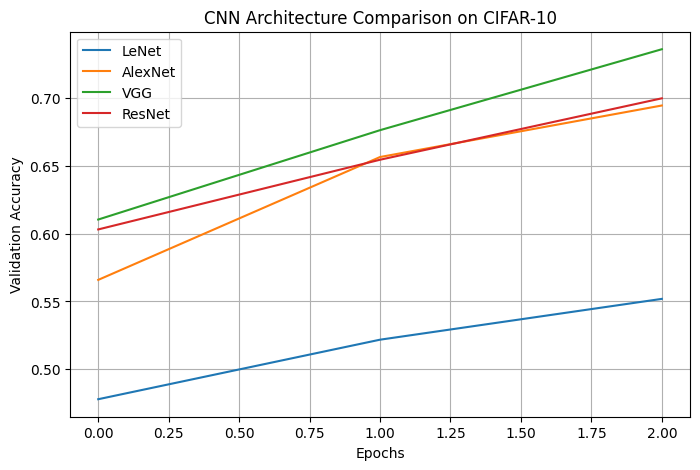


FINAL ACCURACY:
LeNet : 0.5519000291824341
AlexNet : 0.6945000290870667
VGG : 0.7360000014305115
ResNet : 0.6998000144958496


In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ============================================
# 2. LOAD DATASET
# ============================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Shape:", x_train.shape, y_train.shape)

# ============================================
# 3. LENET MODEL (FIXED)
# ============================================
def build_lenet():
    model = models.Sequential([
        layers.Conv2D(6, (5,5), activation='relu', input_shape=(32,32,3)),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Conv2D(16, (5,5), activation='relu'),
        layers.AveragePooling2D(pool_size=(2,2)),

        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# ============================================
# 4. ALEXNET
# ============================================
def build_alexnet():
    model = models.Sequential([
        layers.Conv2D(96, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(384, (3,3), activation='relu'),
        layers.Conv2D(256, (3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# ============================================
# 5. VGG
# ============================================
def build_vgg():
    model = models.Sequential()

    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=(2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

# ============================================
# 6. RESNET STYLE (FIXED)
# ============================================
def res_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)

    # FIX: ensure same shape
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    return x

def build_resnet():
    inputs = layers.Input(shape=(32,32,3))

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(inputs)

    x = res_block(x, 64)
    x = res_block(x, 64)

    x = layers.MaxPooling2D(pool_size=(2,2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    return models.Model(inputs, outputs)

# ============================================
# 7. TRAIN FUNCTION
# ============================================
def train_model(model, name):
    print(f"\nTraining {name}...")

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=64,
        validation_data=(x_test, y_test),
        verbose=1
    )

    return history

# ============================================
# 8. TRAIN ALL MODELS
# ============================================
models_dict = {
    "LeNet": build_lenet(),
    "AlexNet": build_alexnet(),
    "VGG": build_vgg(),
    "ResNet": build_resnet()
}

histories = {}

for name, model in models_dict.items():
    histories[name] = train_model(model, name)

# ============================================
# 9. PLOT COMPARISON GRAPH
# ============================================
plt.figure(figsize=(8,5))

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title("CNN Architecture Comparison on CIFAR-10")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

# ============================================
# 10. FINAL ACCURACY PRINT
# ============================================
print("\nFINAL ACCURACY:")
for name, history in histories.items():
    print(name, ":", history.history['val_accuracy'][-1])